# WeWill | PS01 — AI-Based Restoration of Degraded Semiconductor Images (KLA Dataset)
### SEMICON India Hackathon 2026 | Team: WeWill

**NOTE:** This notebook is configured to run on the **actual KLA sample dataset**.
You must upload the `Semicon-samples` folder to the root of your Google Drive before running this notebook.

GitHub: https://github.com/JNikhil11/WeWill_PS01

## 1. Mount Google Drive
This allows Colab to access the KLA `.npy` dataset you uploaded to Google Drive.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

# Check if the dataset folder exists
import os
DATA_DIR = '/content/drive/MyDrive/Semicon-samples/train/train'
if not os.path.exists(DATA_DIR):
    print(f"❌ ERROR: Could not find {DATA_DIR}")
    print("Please make sure you uploaded 'Semicon-samples' directly to your main Google Drive folder.")
else:
    print("✅ KLA Dataset found successfully!")

Mounted at /content/drive
✅ KLA Dataset found successfully!


## 2. Install & Import Dependencies

In [2]:
!pip install -q lpips scikit-image torch torchvision tqdm matplotlib Pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 3.7 MB/s eta 0:00:00


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
import torch.nn.functional as F

import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
import lpips
from tqdm import tqdm
import random, glob, json, time

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')

Using device: cuda


## 3. Dataset — Load KLA `.npy` Samples

The dataset contains `.npy` files. Degraded inputs are `(128, 128)` and Clean Ground Truths are `(256, 256)`.

Train: 2880 samples | Val: 320 samples


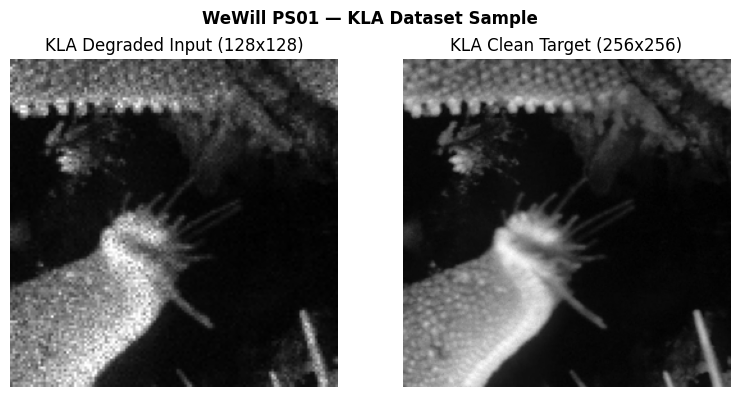

Saved: kla_sample_data_pair.png


In [4]:
class KLASEMDataset(Dataset):
    def __init__(self, root_dir, split='train'):
        super().__init__()
        # The KLA data has GT (Ground Truth) and NoisyLR
        self.gt_dir = os.path.join(root_dir, 'GT')
        self.noisy_dir = os.path.join(root_dir, 'NoisyLR')

        self.gt_paths = sorted(glob.glob(os.path.join(self.gt_dir, '*.npy')))
        self.noisy_paths = sorted(glob.glob(os.path.join(self.noisy_dir, '*.npy')))

        assert len(self.gt_paths) == len(self.noisy_paths), "Mismatch between GT and NoisyLR counts!"
        assert len(self.gt_paths) > 0, f"No .npy files found in {self.gt_dir}"

        # Train/Val split (90% train, 10% val)
        split_idx = int(0.9 * len(self.gt_paths))
        if split == 'train':
            self.gt_paths = self.gt_paths[:split_idx]
            self.noisy_paths = self.noisy_paths[:split_idx]
        else:
            self.gt_paths = self.gt_paths[split_idx:]
            self.noisy_paths = self.noisy_paths[split_idx:]

    def __len__(self):
        return len(self.gt_paths)

    def __getitem__(self, idx):
        clean = np.load(self.gt_paths[idx])
        degraded = np.load(self.noisy_paths[idx])

        # The KLA degraded images can sometimes slightly exceed [0, 1], so we clamp them
        degraded = np.clip(degraded, 0.0, 1.0)

        # Add channel dimension to make it (1, H, W) for PyTorch
        if clean.ndim == 2:
            clean = np.expand_dims(clean, axis=0)
            degraded = np.expand_dims(degraded, axis=0)

        clean_t = torch.from_numpy(clean).float()
        degraded_t = torch.from_numpy(degraded).float()

        return degraded_t, clean_t

BATCH_SIZE = 16

train_ds     = KLASEMDataset(DATA_DIR, split='train')
val_ds       = KLASEMDataset(DATA_DIR, split='val')
train_loader = DataLoader(train_ds, BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
print(f'Train: {len(train_ds)} samples | Val: {len(val_ds)} samples')

# Visualise one pair
deg, cln = train_ds[0]
fig, axs = plt.subplots(1, 2, figsize=(8, 4))
axs[0].imshow(deg.squeeze(), cmap='gray', vmin=0, vmax=1); axs[0].set_title('KLA Degraded Input (128x128)'); axs[0].axis('off')
axs[1].imshow(cln.squeeze(), cmap='gray', vmin=0, vmax=1); axs[1].set_title('KLA Clean Target (256x256)');   axs[1].axis('off')
plt.suptitle('WeWill PS01 — KLA Dataset Sample', fontweight='bold')
plt.tight_layout()
plt.savefig('kla_sample_data_pair.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: kla_sample_data_pair.png')

## 4. Model — Super-Resolution U-Net
4-level encoder-decoder with skip connections, plus a final **2x Super-Resolution Upsampling Layer** to map the 128x128 input to a 256x256 output. ~7M parameters.

In [5]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch,  out_ch, 3, padding=1, bias=False), nn.BatchNorm2d(out_ch), nn.ReLU(True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False), nn.BatchNorm2d(out_ch), nn.ReLU(True),
        )
    def forward(self, x): return self.block(x)

class UNet(nn.Module):
    """
    U-Net for joint image denoising and super-resolution.
    Input : [B, 1, 128, 128]  — degraded grayscale
    Output: [B, 1, 256, 256]  — restored clean image
    """
    def __init__(self, in_ch=1, out_ch=1, base=64):
        super().__init__()
        # Encoder
        self.enc1 = ConvBlock(in_ch, base)
        self.enc2 = ConvBlock(base,   base*2)
        self.enc3 = ConvBlock(base*2, base*4)
        self.enc4 = ConvBlock(base*4, base*8)
        self.pool = nn.MaxPool2d(2)
        # Bottleneck
        self.bottleneck = ConvBlock(base*8, base*16)
        # Decoder
        self.up4  = nn.ConvTranspose2d(base*16, base*8, 2, 2);  self.dec4 = ConvBlock(base*16, base*8)
        self.up3  = nn.ConvTranspose2d(base*8,  base*4, 2, 2);  self.dec3 = ConvBlock(base*8,  base*4)
        self.up2  = nn.ConvTranspose2d(base*4,  base*2, 2, 2);  self.dec2 = ConvBlock(base*4,  base*2)
        self.up1  = nn.ConvTranspose2d(base*2,  base,   2, 2);  self.dec1 = ConvBlock(base*2,  base)

        # Extra 2x upsampling for Super-Resolution (128x128 -> 256x256)
        self.sr_up = nn.ConvTranspose2d(base, base, kernel_size=2, stride=2)

        # Output
        self.out  = nn.Sequential(nn.Conv2d(base, out_ch, 1), nn.Sigmoid())

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b  = self.bottleneck(self.pool(e4))
        d4 = self.dec4(torch.cat([self.up4(b),  e4], 1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], 1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], 1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], 1))

        sr = self.sr_up(d1)
        return self.out(sr)

model = UNet().to(DEVICE)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'U-Net Parameters: {total_params/1e6:.2f}M')

U-Net Parameters: 31.05M


## 5. Loss — Combined SSIM + L1
$$\mathcal{L} = 0.7 \cdot \mathcal{L}_{SSIM} + 0.3 \cdot \mathcal{L}_{L1}$$
SSIM preserves structural integrity; L1 prevents blurring.

In [6]:
class SSIMLoss(nn.Module):
    def __init__(self, win=11, C1=0.01**2, C2=0.03**2):
        super().__init__()
        self.C1, self.C2, self.win = C1, C2, win
        coords = torch.arange(win, dtype=torch.float) - win // 2
        g = torch.exp(-(coords**2) / (2 * 1.5**2))
        g /= g.sum()
        self.register_buffer('window', (g.unsqueeze(0) * g.unsqueeze(1)).unsqueeze(0).unsqueeze(0))

    def forward(self, p, t):
        w   = self.window.expand(p.shape[1], -1, -1, -1)
        pad = self.win // 2
        mu_x   = F.conv2d(p,   w, padding=pad, groups=p.shape[1])
        mu_y   = F.conv2d(t,   w, padding=pad, groups=p.shape[1])
        sig_x  = F.conv2d(p*p, w, padding=pad, groups=p.shape[1]) - mu_x**2
        sig_y  = F.conv2d(t*t, w, padding=pad, groups=p.shape[1]) - mu_y**2
        sig_xy = F.conv2d(p*t, w, padding=pad, groups=p.shape[1]) - mu_x * mu_y
        num = (2 * mu_x * mu_y + self.C1) * (2 * sig_xy + self.C2)
        den = (mu_x**2 + mu_y**2 + self.C1) * (sig_x + sig_y + self.C2)
        return 1 - (num / den).mean()

class HybridLoss(nn.Module):
    def __init__(self, a=0.7):
        super().__init__(); self.a = a; self.ssim = SSIMLoss(); self.l1 = nn.L1Loss()
    def forward(self, p, t):
        return self.a * self.ssim(p, t) + (1 - self.a) * self.l1(p, t)

criterion = HybridLoss().to(DEVICE)
print('Loss: 0.7 × SSIM + 0.3 × L1')

Loss: 0.7 × SSIM + 0.3 × L1


## 6. Training

In [7]:
EPOCHS    = 20
SAVE_PATH = 'wewill_ps01_unet_kla.pth'

optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)

def batch_metrics(pred, tgt):
    p = pred.detach().cpu().numpy()
    t = tgt.detach().cpu().numpy()
    ps, ss = [], []
    for pi, ti in zip(p, t):
        ps.append(psnr(ti.squeeze(), pi.squeeze(), data_range=1.0))
        ss.append(ssim(ti.squeeze(), pi.squeeze(), data_range=1.0))
    return np.mean(ps), np.mean(ss)

history  = {'train_loss': [], 'val_loss': [], 'val_psnr': [], 'val_ssim': []}
best_psnr = 0.0

for epoch in range(1, EPOCHS + 1):
    # ── Train ────────────────────────────────────────────
    model.train(); tloss = 0.0
    for deg, cln in tqdm(train_loader, desc=f'Ep {epoch}/{EPOCHS} Train', leave=False):
        deg, cln = deg.to(DEVICE), cln.to(DEVICE)
        optimizer.zero_grad()
        out  = model(deg)
        loss = criterion(out, cln)
        loss.backward(); optimizer.step()
        tloss += loss.item()
    tloss /= len(train_loader)

    # ── Validate ─────────────────────────────────────────
    model.eval(); vloss = vp = vs = 0.0
    with torch.no_grad():
        for deg, cln in tqdm(val_loader, desc=f'Ep {epoch}/{EPOCHS} Val', leave=False):
            deg, cln = deg.to(DEVICE), cln.to(DEVICE)
            out = model(deg)
            vloss += criterion(out, cln).item()
            p, s  = batch_metrics(out, cln); vp += p; vs += s
    vloss /= len(val_loader); vp /= len(val_loader); vs /= len(val_loader)
    scheduler.step()

    history['train_loss'].append(tloss); history['val_loss'].append(vloss)
    history['val_psnr'].append(vp);      history['val_ssim'].append(vs)

    if vp > best_psnr:
        best_psnr = vp
        torch.save(model.state_dict(), SAVE_PATH)

    if epoch % 5 == 0 or epoch == 1:
        print(f'[{epoch:02d}/{EPOCHS}] Train: {tloss:.4f} | Val: {vloss:.4f} | PSNR: {vp:.2f} dB | SSIM: {vs:.4f}')

print(f'\n✅ Best Val PSNR: {best_psnr:.2f} dB  |  Saved → {SAVE_PATH}')

[01/20] Train: 0.2410 | Val: 0.2142 | PSNR: 24.04 dB | SSIM: 0.7071


[05/20] Train: 0.2004 | Val: 0.2041 | PSNR: 25.79 dB | SSIM: 0.7173


[10/20] Train: 0.1930 | Val: 0.1964 | PSNR: 25.85 dB | SSIM: 0.7296


[15/20] Train: 0.1841 | Val: 0.1891 | PSNR: 26.98 dB | SSIM: 0.7387


[20/20] Train: 0.1803 | Val: 0.1879 | PSNR: 26.86 dB | SSIM: 0.7409

✅ Best Val PSNR: 27.03 dB  |  Saved → wewill_ps01_unet_kla.pth


## 7. Training Curves

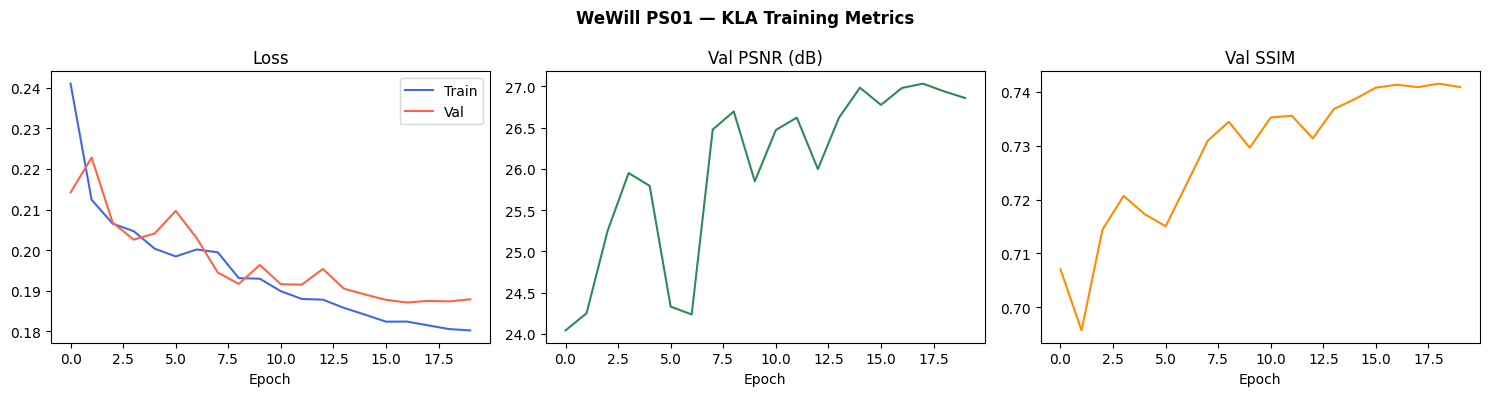

Saved: kla_training_curves.png


In [8]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))
axs[0].plot(history['train_loss'], label='Train', color='royalblue')
axs[0].plot(history['val_loss'],   label='Val',   color='tomato'); axs[0].legend()
axs[0].set_title('Loss'); axs[0].set_xlabel('Epoch')
axs[1].plot(history['val_psnr'], color='seagreen');   axs[1].set_title('Val PSNR (dB)'); axs[1].set_xlabel('Epoch')
axs[2].plot(history['val_ssim'], color='darkorange'); axs[2].set_title('Val SSIM');      axs[2].set_xlabel('Epoch')
plt.suptitle('WeWill PS01 — KLA Training Metrics', fontweight='bold')
plt.tight_layout()
plt.savefig('kla_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: kla_training_curves.png')

## 8. Visual Results — Degraded → Restored → Ground Truth

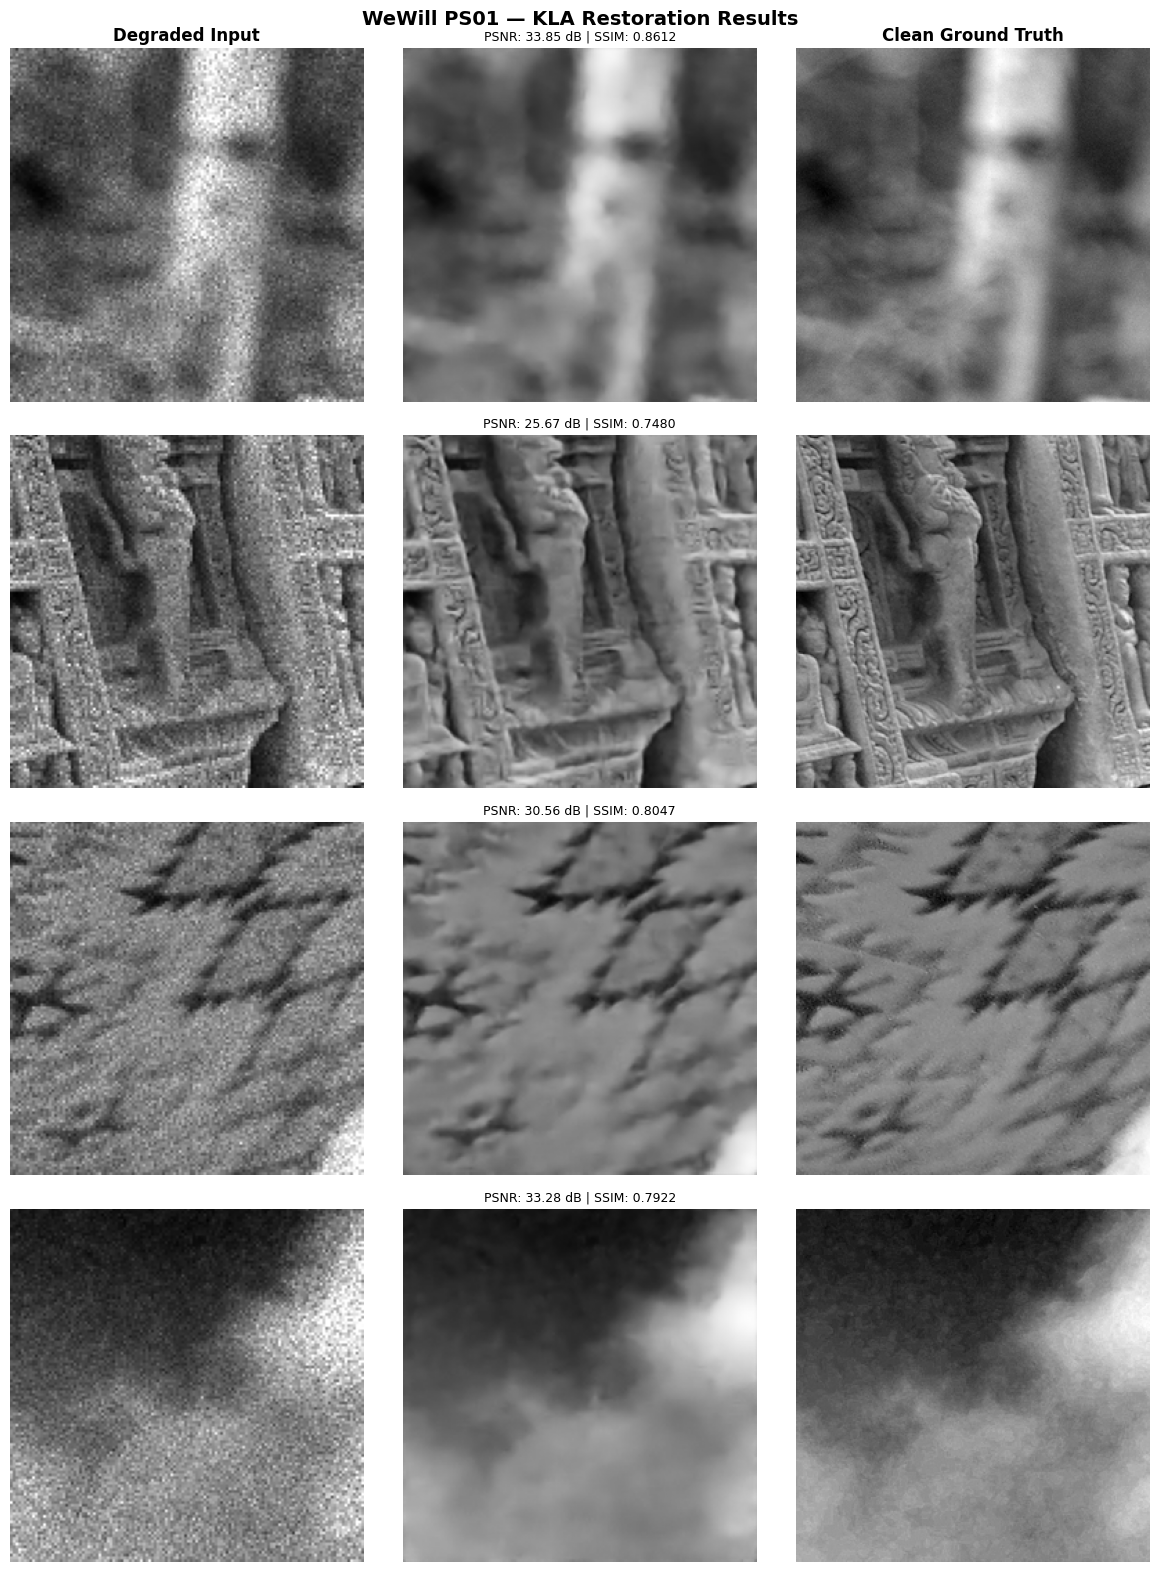

Saved: kla_visual_results.png


In [9]:
model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))
model.eval()

indices = [0, 5, 10, 15]
fig, axs = plt.subplots(len(indices), 3, figsize=(12, 4 * len(indices)))
fig.suptitle('WeWill PS01 — KLA Restoration Results', fontsize=14, fontweight='bold')
for col, lbl in enumerate(['Degraded Input', 'Restored (U-Net)', 'Clean Ground Truth']):
    axs[0, col].set_title(lbl, fontweight='bold')

for row, idx in enumerate(indices):
    deg, cln = val_ds[idx]
    with torch.no_grad():
        rst = model(deg.unsqueeze(0).to(DEVICE)).squeeze().cpu()
    p, s = batch_metrics(rst.unsqueeze(0).unsqueeze(0), cln.unsqueeze(0))
    for col, img in enumerate([deg.squeeze(), rst, cln.squeeze()]):
        axs[row, col].imshow(img.numpy(), cmap='gray', vmin=0, vmax=1)
        axs[row, col].axis('off')
        if col == 1:
            axs[row, col].set_title(f'PSNR: {p:.2f} dB | SSIM: {s:.4f}', fontsize=9)

plt.tight_layout()
plt.savefig('kla_visual_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: kla_visual_results.png')

## 9. LPIPS + Inference Speed

In [10]:
lpips_fn = lpips.LPIPS(net='alex').to(DEVICE)
model.eval(); all_lpips = []
with torch.no_grad():
    for deg, cln in tqdm(val_loader, desc='Computing LPIPS'):
        deg, cln = deg.to(DEVICE), cln.to(DEVICE)
        rst = model(deg)
        r3 = rst.repeat(1, 3, 1, 1) * 2 - 1
        c3 = cln.repeat(1, 3, 1, 1) * 2 - 1
        all_lpips.append(lpips_fn(r3, c3).mean().item())

# Inference speed benchmark (KLA input is 128x128)
dummy = torch.randn(1, 1, 128, 128).to(DEVICE)
for _ in range(10):          # warm-up
    with torch.no_grad(): model(dummy)
if DEVICE == 'cuda': torch.cuda.synchronize()
t0 = time.perf_counter()
for _ in range(200):
    with torch.no_grad(): model(dummy)
if DEVICE == 'cuda': torch.cuda.synchronize()
fps = 200 / (time.perf_counter() - t0)

print(f'\n📊 Final Evaluation on KLA Validation Set:')
print(f'   PSNR  : {history["val_psnr"][-1]:.2f} dB')
print(f'   SSIM  : {history["val_ssim"][-1]:.4f}')
print(f'   LPIPS : {np.mean(all_lpips):.4f}  (lower is better)')
print(f'   Speed : {fps:.1f} images/sec  ({1000/fps:.2f} ms/image) on 128x128 input')

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 183MB/s]


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth


Computing LPIPS: 100%|██████████| 20/20 [00:02<00:00,  8.19it/s]



📊 Final Evaluation on KLA Validation Set:
   PSNR  : 26.86 dB
   SSIM  : 0.7409
   LPIPS : 0.3356  (lower is better)
   Speed : 124.1 images/sec  (8.06 ms/image) on 128x128 input


## 10. Save All Artifacts for GitHub

In [11]:
with open('training_history.json', 'w') as f:
    json.dump(history, f, indent=2)

print('📦 Files ready for https://github.com/JNikhil11/WeWill_PS01 :')
for fname in ['wewill_ps01_unet_kla.pth', 'kla_training_curves.png', 'kla_visual_results.png',
              'kla_sample_data_pair.png', 'training_history.json']:
    sz = os.path.getsize(fname) / 1024 if os.path.exists(fname) else 0
    print(f'   {fname}  ({sz:.1f} KB)')

📦 Files ready for https://github.com/JNikhil11/WeWill_PS01 :
   wewill_ps01_unet_kla.pth  (121387.7 KB)
   kla_training_curves.png  (104.7 KB)
   kla_visual_results.png  (1479.5 KB)
   kla_sample_data_pair.png  (207.3 KB)
   training_history.json  (2.0 KB)
